# AAI 510 Final Project – Data Engineering Pipeline

## Customer Complaint Analysis & Escalation Agent

### Objective
This notebook prepares the Financial Consumer Complaints dataset for retrieval-augmented generation (RAG) workflows. The pipeline loads raw complaint data, performs data quality checks, applies PII masking, creates cleaned Delta tables, and prepares the data for Databricks Vector Search.

### Dataset
- Dataset: Financial Consumer Complaints Dataset
- Source: Kaggle Consumer Complaints Dataset
- Raw Table: main.default.consumer_complaints_raw

### Deliverables
1. Load Raw Complaint Data
2. Validation and Quality Checks
* 2.1 Data Quality Assessment
* 2.2 Exploratory Data Analysis (visuals)
3. Data Cleaning and Preprocessing
4. PII Masking for Responsible AI Compliance
5. Creation of Cleaned CFPB Table
6. Prepare Retrieval Text
7. Build Vector Search Index
8. Validation Queries

## 1. Load Raw Complaint Data

- Load table
- Row and column count
- Schema
- Sample records

The CFPB dataset was loaded through the Databricks Catalog interface due to its large size. The raw complaint data was stored as a Unity Catalog table and used as the source for all subsequent data quality, cleaning, and retrieval preparation steps.

In [0]:
# Quick check: confirm the table exists and preview the first few rows
df = spark.table("main.default.consumer_complaints_raw")

print(f"Row count: {df.count():,}")
print(f"Columns: {len(df.columns)}")
print(f"Columns: {df.columns}")

df.printSchema()

display(df.limit(5))

Row count: 4,522,250
Columns: 18
Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']
root
 |-- Date received: date (nullable = true)
 |-- Product: string (nullable = true)
 |-- Sub-product: string (nullable = true)
 |-- Issue: string (nullable = true)
 |-- Sub-issue: string (nullable = true)
 |-- Consumer complaint narrative: string (nullable = true)
 |-- Company public response: string (nullable = true)
 |-- Company: string (nullable = true)
 |-- State: string (nullable = true)
 |-- ZIP code: string (nullable = true)
 |-- Tags: string (nullable = true)
 |-- Consumer consent provided?: string (nullable = true)
 |-- Submitted via: string (nullable = true)
 |-- Date sent to company: date (nullable = true)
 |--

Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
2021-04-15,Debt collection,Other debt,Attempts to collect debt not owed,Debt was paid,null,Company disputes the facts presented in the complaint,"The CMI Group, Inc.",IL,60202,null,Consent not provided,Web,2021-04-21,Closed with non-monetary relief,Yes,N/A,4299634
2015-04-22,Credit card,null,Sale of account,null,"WellsFargo Bank N.A. Credit Card Limit Increased I obtained a credit card through Wellsfargo at age XXXX, upon beginning my university career. From age XXXX to the present, over XXXX seeing through my responsibility my credit card payments has been a priority. Upon losing my full time employment position in XXXX due to the recession, I was provided with a severance pay equal to a little over {$8000.00}. At the time I owed Wellsfargo Bank 's Credit Card company about {$8000.00}. I paid the balance in full.",null,null,null,null,null,null,null,null,null,null,null,null
null,my income was below the poverty line. I took the XXXX and made it into XXXX School. In XXXX,a period in which I made an income lower than the poverty line and later as a XXXX student Wellsfargo continued to raise the credit limit on the credit card issued to me until it reached about {$20000.00}. In addition,while having no stable source of income and as a student they provided me with a personal line of credit in the amount of {$9000.00}. They did so,without my requesting them to do so,and without taking into consideration whether or not I was employed,nor taking into consideration my income.,null,null,null,null,null,null,null,null,null,null,null
null,I was extended the great privilege of accessing a incredible job offer where my income would have been above {$90000.00} per year. The XXXX exam,however,has been a barrier. I did not pass the exam the XXXX time ( XXXX XXXX exam ). I had to take the exam a XXXX time,with no income and while unemployed,I was forced to look to my Credit Card and my Personal Line of Credit to take on that XXXX exam endeavor XXXX more time.,null,null,null,null,null,null,null,null,null,null,null,null
null,a student,and that I could foresee a struggle with payments. I requested a Forbearance similar to Federal school loans. They informed me they could do nothing to help me and was asked to pay an even greater amount of money than my original required amount that month.,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null


## 2 Validation and Quality Checks

### 2.1 Data Quality Assessment
This section evaluates the quality of the raw consumer complaints dataset before data preparation and indexing. The validation process includes:

- Missing values
- Duplicate records
- Unique values
- Summary statistics

The results of these checks will guide the preprocessing steps used to create a clean and reliable dataset for the customer complaint analysis pipeline.



In [0]:
from pyspark.sql.functions import col, sum as spark_sum, countDistinct

# Missing values by column
missing_values = df.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])

display(missing_values)

Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
1429111,546272,925888,805315,1559272,3086923,2972350,1413045,1451227,1453910,3822631,1519316,1421983,1750668,1718324,1757723,1780412,1823666


In [0]:
# Duplicate record check
total_rows = df.count()
unique_rows = df.dropDuplicates().count()
duplicate_rows = total_rows - unique_rows

print(f"Total rows: {total_rows:,}")
print(f"Unique rows: {unique_rows:,}")
print(f"Duplicate rows: {duplicate_rows:,}")

Total rows: 4,522,250
Unique rows: 3,906,728
Duplicate rows: 615,522


In [0]:
# Unique values in key columns
key_columns = [
    "Product",
    "Issue",
    "Company",
    "State",
    "Submitted via",
    "Company response to consumer"
]

unique_counts = df.select([
    countDistinct(col(c)).alias(c)
    for c in key_columns
    if c in df.columns
])

display(unique_counts)

Product,Issue,Company,State,Submitted via,Company response to consumer
530249,217317,62187,44875,234387,50505


In [0]:
# Summary statistics for available columns
display(df.describe())

summary Product Sub-product Issue Sub-issue Consumer complaint narrative Company public response Company State ZIP code Tags Consumer consent provided? Submitted via Company response to consumer Timely response? Consumer disputed? Complaint ID count 3975978 3596362 3716935 2962978 1435327 1549900 3109205 3071023 3068340 699619 3002934 3100267 2803926 2764527 2741838 2698584 mean 1488.1116301512782 1255.8296846071046 5730.367271214643 50058.35416995651 50654.71019063964 49328.63891362399 49942.04788108254 49888.35826162665 48276.764769732414 52099.67786800439 131337.34524294073 4061594.868483408 3622597.391920475 3589248.0386997377 3493315.5124385976 3450143.414294682 stddev 883.3272976182457 981.2930966507909 16458.11075552354 29913.48069936325 30871.634902150636 30719.184471898232 30797.38269998098 30698.919116831872 31844.92411814262 98786.13075173498 666891.4963560813 1366698.626849213 1455812.4481028763 1499745.0322383605 1568612.7391322406 1669069.5941167274 min XXXX XXXX XXXX I have been waiting to get this issue resolve entirely since XX/XX/2019. Hours turned into days 0 max  whom I bank with. I have subsequently canceled ” constitutes RESPONDENT’S “Breach of Duty” and voluntary agreement to compensate Claimant youarenotliableforthosetransactionsifyoureportthemwithin60daysofyourstatementbeingsenttoyou. you are duly bound to pay in full Citibank""!!! •	School Loan servicer XXXX defaulted my loans while I was paying on them•	XXXX never informed even though they continued to take my payments•	XXXX sent (so they said) a default notice to an address I had not been at in over 5 years•	XXXX sent correspondences within those 5 years to my current address but sends this very important notice to an old address.•	I had already had a claim in with Attn Gen on them because they pulled a bait and switch on me with a forbearance request that automatically excluded me from loan payment reduction programs and did not disclose.•	I believe they sold my loans because of the claim. The consumer affairs office said the claim needed to be resent with the new information to the original issue. I did that.•	ECMC was the new loan company and before I even knew they had my loans or what happened they tacked on XXXX in collection fees. I have been paying on these loans for almost 10 years, the interest was taken first and my original amount of XXXX was only down to XXXX principle. Now, after collection costs it is XXXX.•	ECMC reached out to me at work and said I needed to immediately pay them etc. and that is when I found out what happened. From XX/XX/XXXX when XXXX sold the loans to XX/XX/XXXX had no idea, was still just paying my loans.•	I reached out to a lawyer – he asked me to have ECMC send all documentation via certified mail of everything they had done without my knowledge since the bought the loans.•	XX/XX/XXXX I get the packet, except that they already sent a notice of wage garnishment out, to the same address XXXX used, however they never included a copy in that packet. My company never received notice either.•	When my company found out by notice of penalty for non-compliance, they contacted me. I had no clue and neither did they. I called ECMC immediately and they had me send in a request for a hearing but said it was probably too late.•	I sent the letter immediately but they still garnished my wages taking the max amount which over the next two months fighting them almost made me homeless.•	I finally got the Ombudsman involved but they just gave me the run around. I have all documentation. They side-stepped the fact that they never included the garnishment notice and in the end stood behind the Dept of Ed code as a response.•	I called the lawyer that was working with me but he dropped off the earth.•	The Consumer Affairs woman handling the XXXX case said that my case would be part of the class action. So I went back to the board restating my loan should have never been in default so they let me appeal the decision, but that was denied

The dataset contains 4.5 million complaint records across 18 columns, providing a large and diverse source of customer complaint data.

Several columns contain missing values, particularly optional fields such as complaint narratives and company public responses. A duplicate check identified approximately 615,000 duplicate records, which will be addressed during preprocessing to improve data quality.

The dataset also contains a wide variety of products, issues, companies, and customer response outcomes, making it well suited for complaint classification, retrieval, and escalation workflows. Overall, the data quality assessment confirms that the dataset is appropriate for further cleaning, PII masking, and vector search preparation.



### 2.2 Exploratory Data Analysis (visuals)
- Top 10 Complaint Products
- Top 10 States by Complaint Volume
- Complaint Trends Over Time

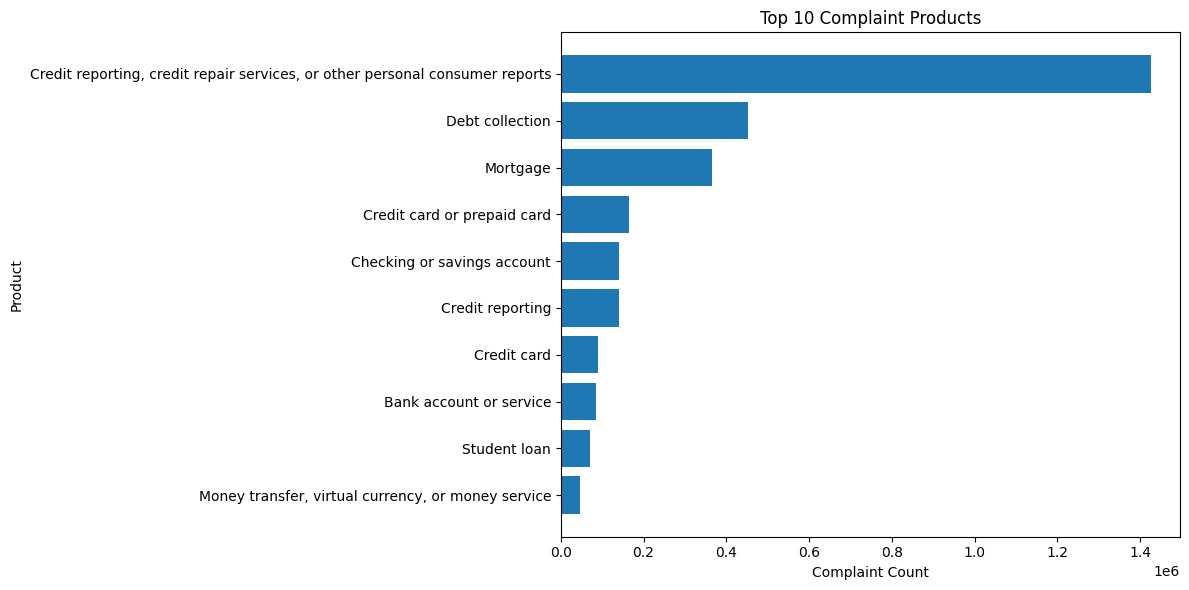

In [0]:
# Exploratory Data Analysis (EDA) Visuals for CFPB Complaints
import pyspark.sql.functions as F
import matplotlib.pyplot as plt

# 1. Top 10 complaint products
top_products = (
    df.filter(F.col("Product").isNotNull())
      .filter(~F.col("Product").contains("Company has responded"))
      .groupBy("Product")
      .count()
      .orderBy(F.desc("count"))
      .limit(10)
      .toPandas()
)

plt.figure(figsize=(12, 6))
plt.barh(top_products["Product"], top_products["count"])
plt.xlabel("Complaint Count")
plt.ylabel("Product")
plt.title("Top 10 Complaint Products")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

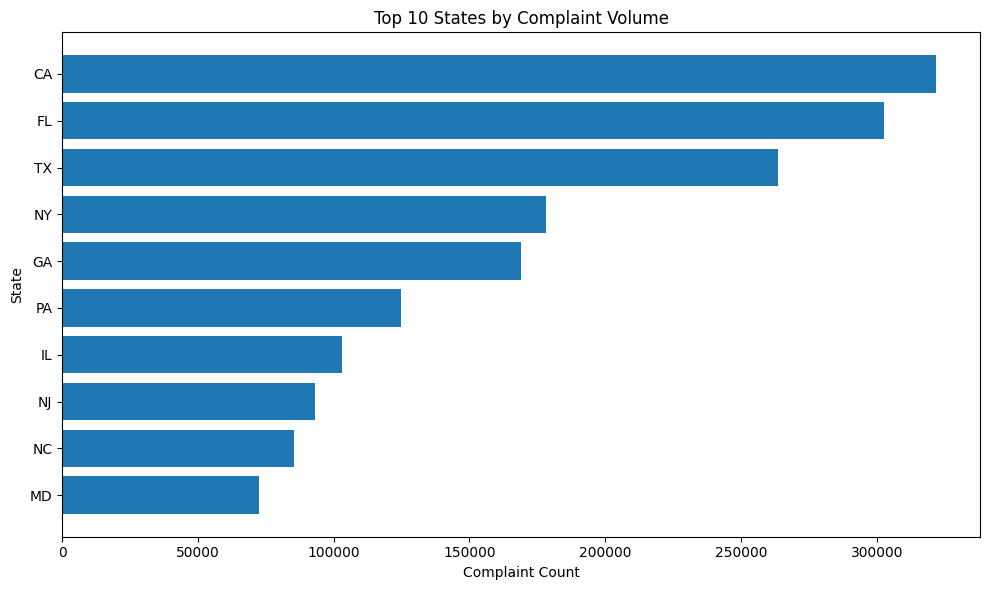

In [0]:

# 2. Top 10 states by complaint volume
top_states = (
    df.filter(F.col("State").isNotNull())
      .filter(F.length(F.col("State")) == 2)  # keep only state abbreviations
      .groupBy("State")
      .count()
      .orderBy(F.desc("count"))
      .limit(10)
      .toPandas()
)

plt.figure(figsize=(10, 6))
plt.barh(top_states["State"], top_states["count"])
plt.xlabel("Complaint Count")
plt.ylabel("State")
plt.title("Top 10 States by Complaint Volume")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


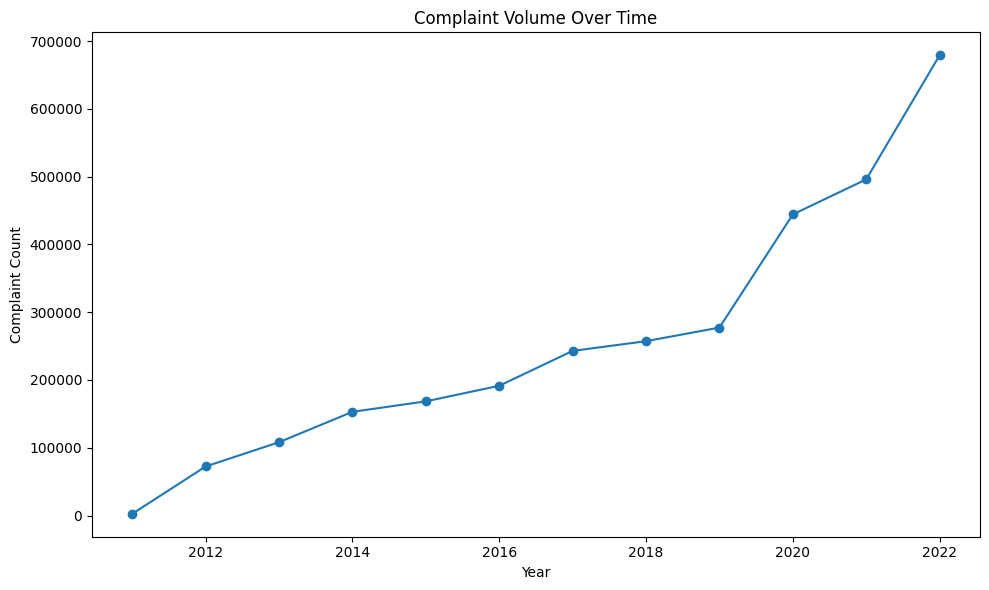

In [0]:
# 3. Complaints over time by year
complaints_by_year = (
    df.withColumn("year", F.year("Date received"))
      .filter(F.col("year").between(2011, 2026))
      .groupBy("year")
      .count()
      .orderBy("year")
      .toPandas()
)

plt.figure(figsize=(10, 6))
plt.plot(complaints_by_year["year"], complaints_by_year["count"], marker="o")
plt.xlabel("Year")
plt.ylabel("Complaint Count")
plt.title("Complaint Volume Over Time")
plt.tight_layout()
plt.show()


### 3. Data Cleaning and Preprocessing

This section prepares the raw CFPB complaint data for responsible AI processing and retrieval. The cleaning process removes duplicate records, selects relevant complaint fields, standardizes text formatting, and prepares the dataset for PII masking and vector search indexing.

During data cleaning, obvious malformed records containing response text or placeholder values in the Product field were removed to improve data quality before retrieval and indexing. While this filtering improved overall data quality, some minor inconsistencies may remain in the source data.

In [0]:
# Select columns relevant to complaint analysis and escalation workflows
selected_columns = [
    "Date received",
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Consumer complaint narrative",
    "Company public response",
    "Company",
    "State",
    "ZIP code",
    "Submitted via",
    "Date sent to company",
    "Company response to consumer",
    "Timely response?",
    "Consumer disputed?",
    "Complaint ID"
]

# Create cleaned dataframe from raw dataframe
cleaned_df = df.select(*selected_columns)

display(cleaned_df.limit(5))

Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
2021-04-15,Debt collection,Other debt,Attempts to collect debt not owed,Debt was paid,null,Company disputes the facts presented in the complaint,"The CMI Group, Inc.",IL,60202,Web,2021-04-21,Closed with non-monetary relief,Yes,N/A,4299634
2015-04-22,Credit card,null,Sale of account,null,"WellsFargo Bank N.A. Credit Card Limit Increased I obtained a credit card through Wellsfargo at age XXXX, upon beginning my university career. From age XXXX to the present, over XXXX seeing through my responsibility my credit card payments has been a priority. Upon losing my full time employment position in XXXX due to the recession, I was provided with a severance pay equal to a little over {$8000.00}. At the time I owed Wellsfargo Bank 's Credit Card company about {$8000.00}. I paid the balance in full.",null,null,null,null,null,null,null,null,null,null
null,my income was below the poverty line. I took the XXXX and made it into XXXX School. In XXXX,a period in which I made an income lower than the poverty line and later as a XXXX student Wellsfargo continued to raise the credit limit on the credit card issued to me until it reached about {$20000.00}. In addition,while having no stable source of income and as a student they provided me with a personal line of credit in the amount of {$9000.00}. They did so,without my requesting them to do so,and without taking into consideration whether or not I was employed,nor taking into consideration my income.,null,null,null,null,null,null,null,null,null
null,I was extended the great privilege of accessing a incredible job offer where my income would have been above {$90000.00} per year. The XXXX exam,however,has been a barrier. I did not pass the exam the XXXX time ( XXXX XXXX exam ). I had to take the exam a XXXX time,with no income and while unemployed,I was forced to look to my Credit Card and my Personal Line of Credit to take on that XXXX exam endeavor XXXX more time.,null,null,null,null,null,null,null,null,null,null
null,a student,and that I could foresee a struggle with payments. I requested a Forbearance similar to Federal school loans. They informed me they could do nothing to help me and was asked to pay an even greater amount of money than my original required amount that month.,null,null,null,null,null,null,null,null,null,null,null,null,null


In [0]:
# Standardize text fields by trimming spaces and reducing extra whitespace
from pyspark.sql.functions import col, regexp_replace, trim

text_columns = [
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Consumer complaint narrative",
    "Company public response",
    "Company",
    "State",
    "Submitted via",
    "Company response to consumer"
]

for column_name in text_columns:
    cleaned_df = cleaned_df.withColumn(
        column_name,
        trim(regexp_replace(col(column_name), r"\s+", " "))
    )

display(cleaned_df.limit(5))

Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
null,we have validated the debt for the consumer more than once.,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2021-12-03,Debt collection,Other debt,Attempts to collect debt not owed,Debt was result of identity theft,null,null,Regional Management Corporation,TX,77453,Web,2021-12-03,Closed with explanation,Yes,N/A,4973525
2020-03-02,"Credit reporting, credit repair services, or other personal consumer reports",Other personal consumer report,Incorrect information on your report,Information belongs to someone else,This information reporting on my reports and to third party creditors I dont know the addresses or information listed on the report it is not mine. And my name is even inaccurate.I couldn't obtain XXXX or XXXX they wouldn't give me my free report they report to outside agencies. I am disputing this information. Its preventing me from getting proper housing.,null,null,null,null,null,null,null,null,null,null
null,I now get a call from PenFed claiming I've missed TWO payments on the loan,and my credit reports now showed two late payments as well. I asked why this was the case when I didn't even receive a check to deposit until a couple of days prior. My loan shouldn't have started until that point. I was told by the person on the phone that their personnel who I had reported the bad check to had failed to cancel the previous check,so my loan was still dated in XXXX,and I owed the payments stated,and there was nothing they could do since I already deposited the check ( otherwise I likely would have simply canceled the loan ).,null,null,null,null,null,null,null,null,null,null
2021-12-08,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Problem with a credit reporting company's investigation into an existing problem,Investigation took more than 30 days,null,Company has responded to the consumer and the CFPB and chooses not to provide a public response,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",IL,60803,Web,2021-12-08,Closed with non-monetary relief,Yes,N/A,4986937


In [0]:
# Remove malformed records where Product contains response text
invalid_products = [
    "Company has responded to the consumer and the CFPB and chooses not to provide a public response",
    "Company believes it acted appropriately as authorized by contract or law",
    "XXXX"
]

cleaned_df = cleaned_df.filter(
    col("Product").isNotNull() &
    ~col("Product").isin(invalid_products)
)

In [0]:
# Final duplicate removal after all cleaning steps
cleaned_df = cleaned_df.dropDuplicates()

print(f"Final row count: {cleaned_df.count():,}")

Final row count: 3,668,944


In [0]:
# Verify cleaned dataset

print(f"Rows after cleaning: {cleaned_df.count():,}")
print(f"Columns after cleaning: {len(cleaned_df.columns)}")

# Check for remaining duplicate records
remaining_duplicates = cleaned_df.count() - cleaned_df.dropDuplicates().count()
print(f"Remaining duplicate records: {remaining_duplicates:,}")

display(cleaned_df.limit(10))

Rows after cleaning: 3,668,944
Columns after cleaning: 16
Remaining duplicate records: 0


Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
null,we have validated the debt for the consumer more than once.,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2021-12-03,Debt collection,Other debt,Attempts to collect debt not owed,Debt was result of identity theft,null,null,Regional Management Corporation,TX,77453,Web,2021-12-03,Closed with explanation,Yes,N/A,4973525
2020-03-02,"Credit reporting, credit repair services, or other personal consumer reports",Other personal consumer report,Incorrect information on your report,Information belongs to someone else,This information reporting on my reports and to third party creditors I dont know the addresses or information listed on the report it is not mine. And my name is even inaccurate.I couldn't obtain XXXX or XXXX they wouldn't give me my free report they report to outside agencies. I am disputing this information. Its preventing me from getting proper housing.,null,null,null,null,null,null,null,null,null,null
null,I now get a call from PenFed claiming I've missed TWO payments on the loan,and my credit reports now showed two late payments as well. I asked why this was the case when I didn't even receive a check to deposit until a couple of days prior. My loan shouldn't have started until that point. I was told by the person on the phone that their personnel who I had reported the bad check to had failed to cancel the previous check,so my loan was still dated in XXXX,and I owed the payments stated,and there was nothing they could do since I already deposited the check ( otherwise I likely would have simply canceled the loan ).,null,null,null,null,null,null,null,null,null,null
2021-12-08,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Problem with a credit reporting company's investigation into an existing problem,Investigation took more than 30 days,null,Company has responded to the consumer and the CFPB and chooses not to provide a public response,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",IL,60803,Web,2021-12-08,Closed with non-monetary relief,Yes,N/A,4986937
2019-03-20,Debt collection,I do not know,Attempts to collect debt not owed,Debt was result of identity theft,null,null,"ARS National Services, Inc.",PR,00921,Web,2019-03-20,Closed with explanation,Yes,N/A,3186277
2020-05-17,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Improper use of your report,Reporting company used your report improperly,null,null,"EQUIFAX, INC.",TN,37211,Web,2020-05-17,Closed with explanation,Yes,N/A,3655938
2021-12-08,Debt collection,Credit card debt,Attempts to collect debt not owed,Debt was result of identity theft,I am XXXX XXXX and I am submitting this complaint myself. This account is inaccurately and erroneously reporting. Their intentional and willful furnishing of inaccurate information is a violation of FCRA Section 623 and according to FCRA Section 611. I have done many attempts to reach out to Transunion XXXX XXXX but they failed to give me any results or feedbacks about this concern. Please investigate and remove it from my personal credit file. Thank you.,null,null,null,null,null,null,null,null,null,null
null,and Lending Club did stop calling me.,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2021-12-12,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Incorrect information on your report,Information belongs to someone else,null,Company has responded to the consumer and the CFPB and chooses not to provide a public response,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AL,35405,Web,2021-12-12,Closed with non-monetary relief,Yes,N/A,5000192


## 4. PII Masking for Responsible AI Compliance

This section applies regex-based masking to reduce exposure of sensitive customer information in complaint narratives. The masking process focuses on common personally identifiable information (PII), including email addresses, phone numbers, Social Security numbers, ZIP codes, and long numeric account-like identifiers.

This step supports responsible AI practices by preparing safer complaint text before creating the cleaned CFPB table and building vector search indexes.

In [0]:
from pyspark.sql.functions import regexp_replace, col

# Apply regex-based PII masking to the complaint narrative field
pii_df = cleaned_df.withColumn(
    "Consumer complaint narrative",
    regexp_replace(col("Consumer complaint narrative"), r"[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}", "[EMAIL]")
).withColumn(
    "Consumer complaint narrative",
    regexp_replace(col("Consumer complaint narrative"), r"\b\d{3}[-.\s]?\d{2}[-.\s]?\d{4}\b", "[SSN]")
).withColumn(
    "Consumer complaint narrative",
    regexp_replace(col("Consumer complaint narrative"), r"\b(?:\+?1[-.\s]?)?\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4}\b", "[PHONE]")
).withColumn(
    "Consumer complaint narrative",
    regexp_replace(col("Consumer complaint narrative"), r"\b\d{5}(?:-\d{4})?\b", "[ZIP]")
).withColumn(
    "Consumer complaint narrative",
    regexp_replace(col("Consumer complaint narrative"), r"\b\d{8,}\b", "[ACCOUNT_NUMBER]")
)

display(pii_df.select("Consumer complaint narrative").limit(10))

Consumer complaint narrative
null
null
This information reporting on my reports and to third party creditors I dont know the addresses or information listed on the report it is not mine. And my name is even inaccurate.I couldn't obtain XXXX or XXXX they wouldn't give me my free report they report to outside agencies. I am disputing this information. Its preventing me from getting proper housing.
and there was nothing they could do since I already deposited the check ( otherwise I likely would have simply canceled the loan ).
null
null
null
I am XXXX XXXX and I am submitting this complaint myself. This account is inaccurately and erroneously reporting. Their intentional and willful furnishing of inaccurate information is a violation of FCRA Section 623 and according to FCRA Section 611. I have done many attempts to reach out to Transunion XXXX XXXX but they failed to give me any results or feedbacks about this concern. Please investigate and remove it from my personal credit file. Thank you.
null
null


In [0]:
# Validate PII masking step
print(f"Rows after PII masking: {pii_df.count():,}")
print(f"Columns after PII masking: {len(pii_df.columns)}")

display(pii_df.limit(5))

Rows after PII masking: 3,668,944
Columns after PII masking: 16


Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
null,we have validated the debt for the consumer more than once.,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2021-12-03,Debt collection,Other debt,Attempts to collect debt not owed,Debt was result of identity theft,null,null,Regional Management Corporation,TX,77453,Web,2021-12-03,Closed with explanation,Yes,N/A,4973525
2020-03-02,"Credit reporting, credit repair services, or other personal consumer reports",Other personal consumer report,Incorrect information on your report,Information belongs to someone else,This information reporting on my reports and to third party creditors I dont know the addresses or information listed on the report it is not mine. And my name is even inaccurate.I couldn't obtain XXXX or XXXX they wouldn't give me my free report they report to outside agencies. I am disputing this information. Its preventing me from getting proper housing.,null,null,null,null,null,null,null,null,null,null
null,I now get a call from PenFed claiming I've missed TWO payments on the loan,and my credit reports now showed two late payments as well. I asked why this was the case when I didn't even receive a check to deposit until a couple of days prior. My loan shouldn't have started until that point. I was told by the person on the phone that their personnel who I had reported the bad check to had failed to cancel the previous check,so my loan was still dated in XXXX,and I owed the payments stated,and there was nothing they could do since I already deposited the check ( otherwise I likely would have simply canceled the loan ).,null,null,null,null,null,null,null,null,null,null
2021-12-08,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Problem with a credit reporting company's investigation into an existing problem,Investigation took more than 30 days,null,Company has responded to the consumer and the CFPB and chooses not to provide a public response,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",IL,60803,Web,2021-12-08,Closed with non-monetary relief,Yes,N/A,4986937


The PII masking process successfully preserved complaint context while masking sensitive information. Sample records show that personal identifiers were replaced with masking tokens such as [EMAIL], [PHONE], [SSN], [ZIP], and [ACCOUNT_NUMBER] while maintaining sufficient complaint details for retrieval and analysis. Some records contain missing values that originate from the source dataset rather than the masking process.

## 5. Creation of Cleaned CFPB Table

This section saves the cleaned and PII-masked complaint dataset as a Delta table in Unity Catalog. The cleaned table will be used as the foundation for retrieval, embedding generation, and Databricks Vector Search indexing.

In [0]:
# Create final cleaned CFPB DataFrame
cleaned_cfpb = pii_df

# Rename columns to remove invalid characters for Delta tables
for col_name in cleaned_cfpb.columns:
    new_col_name = (
        col_name.lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("?", "")
    )
    cleaned_cfpb = cleaned_cfpb.withColumnRenamed(col_name, new_col_name)

# Save cleaned and masked dataset as a Delta table
cleaned_cfpb.write.format("delta") \
    .mode("overwrite") \
    .saveAsTable("main.default.cleaned_cfpb")

# Verify the cleaned table
cleaned_cfpb_table = spark.table("main.default.cleaned_cfpb")

print(f"Cleaned CFPB table rows: {cleaned_cfpb_table.count():,}")
print(f"Cleaned CFPB table columns: {len(cleaned_cfpb_table.columns)}")

display(cleaned_cfpb_table.limit(5))

Cleaned CFPB table rows: 3,668,944
Cleaned CFPB table columns: 16


Date_received,Product,Sub_product,Issue,Sub_issue,Consumer_complaint_narrative,Company_public_response,Company,State,ZIP_code,Submitted_via,Date_sent_to_company,Company_response_to_consumer,Timely_response,Consumer_disputed,Complaint_ID
2021-12-08,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Incorrect information on your report,Account status incorrect,"This is XXXX XXXX, who is submitting this CFPB complaint myself, and to inform you that there is no third party involved in the process. Upon reviewing my updates, incorrect information was found in my reports. The Equifax Credit Bureau has not complied with the Fair Credit Reporting Act, 15 USC Sections 1681i, and continued reporting as unverified information without any proof provided, within the time allowed by law, is not authorized. Below are the inquiries that are reporting on my Credit Reports : XXXX XX/XX/2021 XXXX XX/XX/2021 XXXX XX/XX/2021 XXXX XXXX XXXX XX/XX/2021 XXXX XXXX XXXX XX/XX/2021 XXXX XX/XX/2021 XXXX XX/XX/2021 XXXX XXXX XXXX XX/XX/2021 XXXX XX/XX/2021 XXXX XXXX XXXXXX/XX/2021",null,"EQUIFAX, INC.",FL,33884,Web,2021-12-08,Closed with explanation,Yes,N/A,4983888
2020-02-04,Student loan,Federal student loan servicing,Dealing with your lender or servicer,Need information about your loan balance or loan terms,regarding complaints ID XXXX & XXXX I have submitted today and I want to submit additional documents. According to the company response that I never agree with because the information are not true. Please find attached documents for your review.,null,null,null,null,null,null,null,null,null,null
null,and their info is below : XXXX XXXX XXXX.,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2022-09-18,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Improper use of your report,Reporting company used your report improperly,null,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Experian Information Solutions Inc.,FL,32209,Web,2022-09-18,Closed with non-monetary relief,Yes,N/A,5994135
2020-01-09,Checking or savings account,Other banking product or service,Opening an account,Account opened as a result of fraud,null,null,"Paypal Holdings, Inc",DE,19810,Referral,2020-01-10,Closed with explanation,Yes,N/A,3492606


## 6. Prepare Retrieval Text

Duplicate Complaint_ID values were removed so that Complaint_ID can be used as the unique primary key for AI Search indexing.

In [0]:
from pyspark.sql.functions import concat_ws, col, coalesce, lit, length
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

# Load cleaned complaint table
cleaned_cfpb_table = spark.table("main.default.cleaned_cfpb")

# Create retrieval text for vector search
retrieval_df = (
    cleaned_cfpb_table
    .filter(col("Complaint_ID").isNotNull())
    .filter(col("Product").isNotNull())
    .withColumn(
        "retrieval_text",
        concat_ws(
            " ",
            coalesce(col("Product"), lit("")),
            coalesce(col("Sub_product"), lit("")),
            coalesce(col("Issue"), lit("")),
            coalesce(col("Sub_issue"), lit("")),
            coalesce(col("Company"), lit("")),
            coalesce(col("Company_response_to_consumer"), lit("")),
            coalesce(col("Consumer_complaint_narrative"), lit(""))
        )
    )
    .filter(length(col("retrieval_text")) > 50)
)

# Preview retrieval text
display(
    retrieval_df.select(
        "Complaint_ID",
        "retrieval_text"
    ).limit(5)
)

# Ensure Complaint_ID is unique for AI Search primary key
window_spec = Window.partitionBy("Complaint_ID").orderBy(
    col("Date_received").desc_nulls_last()
)

retrieval_df_unique = (
    retrieval_df
    .withColumn("row_num", row_number().over(window_spec))
    .filter(col("row_num") == 1)
    .drop("row_num")
)

# Save retrieval table
retrieval_df_unique.write.format("delta") \
    .mode("overwrite") \
    .saveAsTable("main.default.cleaned_cfpb_retrieval")

# Verify retrieval table
retrieval_table = spark.table("main.default.cleaned_cfpb_retrieval")

print(f"Retrieval table rows: {retrieval_table.count():,}")
print(f"Retrieval table columns: {len(retrieval_table.columns)}")

display(
    retrieval_table.select(
        "Complaint_ID",
        "retrieval_text"
    ).limit(5)
)

Complaint_ID,retrieval_text
3199041,"Credit reporting, credit repair services, or other personal consumer reports Credit reporting Incorrect information on your report Information belongs to someone else EQUIFAX, INC. Closed with non-monetary relief"
4994868,"Credit reporting, credit repair services, or other personal consumer reports Credit reporting Incorrect information on your report Information belongs to someone else TRANSUNION INTERMEDIATE HOLDINGS, INC. Closed with non-monetary relief"
5997043,Mortgage Conventional home mortgage Applying for a mortgage or refinancing an existing mortgage HSBC NORTH AMERICA HOLDINGS INC. Closed with explanation
4992099,"Credit reporting, credit repair services, or other personal consumer reports Credit reporting Improper use of your report Credit inquiries on your report that you don't recognize SYNCHRONY FINANCIAL Closed with non-monetary relief"
4988182,"Credit reporting, credit repair services, or other personal consumer reports Credit reporting Incorrect information on your report Information belongs to someone else TRANSUNION INTERMEDIATE HOLDINGS, INC. Closed with non-monetary relief"


Retrieval table rows: 2,696,974
Retrieval table columns: 17


Complaint_ID,retrieval_text
41,"Mortgage Conventional fixed mortgage Loan modification,collection,foreclosure JPMORGAN CHASE & CO. Closed with explanation"
48,"Mortgage Conventional fixed mortgage Loan modification,collection,foreclosure PHH Mortgage Services Corporation Closed with non-monetary relief"
73,Credit card Credit determination U.S. BANCORP Closed without relief
134,"Credit card Credit line increase/decrease CITIBANK, N.A. Closed without relief"
151,"Credit card Other fee CITIBANK, N.A. Closed with relief"


## 7. Build Vector Search Index

This section prepares the CFPB retrieval data for Databricks AI Search and Vector Search indexing. The full `cleaned_cfpb_retrieval` table contains millions of complaint records, so a smaller 10,000-record sample table, `cleaned_cfpb_retrieval_sample`, was created for development and testing. This approach allows the team to test vector search retrieval and agent integration efficiently while keeping the full retrieval table available for future larger-scale indexing.


In [0]:
%pip install databricks-vectorsearch
dbutils.library.restartPython()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 44.6 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.3
    Not uninstalling requests at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-f011945a-5723-4036-950f-b18a789631de
    Can't uninstall 'requests'. No files were found to uninstall.
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.4
    Not uninstalling protobuf at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-f011945a-5723-4036-950f-b18a789631de
    Can't uninstall 'protobuf'. No files were found to uninstall.
  Attempting uninstall: mlflow-skinny
    Found existing installation: mlflow-skinny 3.8.1
    Not uninstalling mlflow-skinny at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-f011945a-5723-4036-

In [0]:
from databricks.vector_search.client import VectorSearchClient

client = VectorSearchClient()

# Create a smaller retrieval sample for AI Search development/testing
sample_df = spark.table("main.default.cleaned_cfpb_retrieval").limit(10000)

sample_df.write.format("delta") \
    .mode("overwrite") \
    .saveAsTable("main.default.cleaned_cfpb_retrieval_sample")

/home/spark-9004a4f1-1079-4d00-94bd-83/.ipykernel/14357/command-5773986412341363-4184958515:1: DeprecationWarning: databricks-vectorsearch is deprecated and has been renamed to databricks-ai-search. Imports under 'databricks.vector_search.*' will continue to work as a thin re-export of 'databricks.ai_search.*', but new code should switch to 'pip install databricks-ai-search' and 'from databricks.ai_search.* import ...'.
  from databricks.vector_search.client import VectorSearchClient


[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


In [0]:
spark.sql("""
ALTER TABLE main.default.cleaned_cfpb_retrieval_sample
SET TBLPROPERTIES (
  'delta.deletedFileRetentionDuration' = 'interval 30 days',
  'delta.enableChangeDataFeed' = true
)
""")

DataFrame[]

The `cleaned_cfpb_retrieval_sample` table was configured for AI Search synchronization using Change Data Feed. A hybrid AI Search index, `cleaned_cfpb_sample_index`, was created using the Databricks AI Search UI with `retrieval_text` as the embedding source column and `Complaint_ID` as the primary key. Databricks-managed embeddings are generated during index creation, enabling semantic and keyword-based retrieval for downstream customer complaint analysis and escalation workflows.

A 10,000-record sample table was used for development and testing to support efficient indexing and agent integration while preserving the full retrieval dataset for future large-scale indexing.

## 8. Validation Queries

This section validates that the cleaned CFPB retrieval table is ready for downstream AI Search and agent workflows. The queries check that the table contains usable complaint records, valid complaint IDs, and meaningful retrieval text.

In [0]:
# Load retrieval table
retrieval_table = spark.table("main.default.cleaned_cfpb_retrieval")

print(f"Retrieval table rows: {retrieval_table.count():,}")
print(f"Retrieval table columns: {len(retrieval_table.columns)}")

display(retrieval_table.limit(5))

Retrieval table rows: 2,696,974
Retrieval table columns: 17


Date_received,Product,Sub_product,Issue,Sub_issue,Consumer_complaint_narrative,Company_public_response,Company,State,ZIP_code,Submitted_via,Date_sent_to_company,Company_response_to_consumer,Timely_response,Consumer_disputed,Complaint_ID,retrieval_text
2012-05-21,Bank account or service,Checking account,Deposits and withdrawals,null,null,null,WELLS FARGO & COMPANY,CA,90032,Web,2012-05-24,Closed without relief,Yes,No,50,Bank account or service Checking account Deposits and withdrawals WELLS FARGO & COMPANY Closed without relief
2012-05-21,Bank account or service,Other bank product/service,"Making/receiving payments, sending money",null,null,null,EAST WEST BANK,CA,90032,Web,2012-05-24,Closed with explanation,Yes,No,51,"Bank account or service Other bank product/service Making/receiving payments, sending money EAST WEST BANK Closed with explanation"
2012-05-21,Credit card,null,Customer service / Customer relations,null,null,null,BARCLAYS BANK DELAWARE,TX,75088,Web,2012-05-24,Closed with explanation,Yes,No,98,Credit card Customer service / Customer relations BARCLAYS BANK DELAWARE Closed with explanation
2012-05-21,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",null,null,null,Ocwen Financial Corporation,PA,15216,Postal mail,2012-05-24,Closed with non-monetary relief,Yes,No,102,"Mortgage Other mortgage Loan modification,collection,foreclosure Ocwen Financial Corporation Closed with non-monetary relief"
2012-05-21,Credit card,null,Collection debt dispute,null,null,null,SYNCHRONY FINANCIAL,MO,65270,Web,2012-05-23,Closed without relief,Yes,No,147,Credit card Collection debt dispute SYNCHRONY FINANCIAL Closed without relief


In [0]:
# Check records with valid retrieval text
from pyspark.sql.functions import col, length

valid_retrieval_records = retrieval_table.filter(
    col("retrieval_text").isNotNull() & 
    (length(col("retrieval_text")) > 50)
)

print(f"Valid retrieval records: {valid_retrieval_records.count():,}")
display(valid_retrieval_records.select("Complaint_ID", "Product", "Issue", "retrieval_text").limit(5))

Valid retrieval records: 2,696,974


Complaint_ID,Product,Issue,retrieval_text
16,Mortgage,"Loan modification,collection,foreclosure","Mortgage Other mortgage Loan modification,collection,foreclosure UNITED GUARANTY CORPORATION Closed with explanation"
20,Mortgage,"Loan modification,collection,foreclosure","Mortgage Other mortgage Loan modification,collection,foreclosure HSBC NORTH AMERICA HOLDINGS INC. Closed with non-monetary relief"
22,Credit card,Late fee,Credit card Late fee WELLS FARGO & COMPANY Closed with relief
27,Mortgage,"Loan modification,collection,foreclosure","Mortgage Other mortgage Loan modification,collection,foreclosure Ocwen Financial Corporation Closed with explanation"
37,Mortgage,"Loan modification,collection,foreclosure","Mortgage Other mortgage Loan modification,collection,foreclosure NATIONSTAR MORTGAGE Closed with non-monetary relief"


In [0]:
# Sample query-style validation: identity theft complaints
identity_theft_examples = retrieval_table.filter(
    col("retrieval_text").contains("identity theft")
)

print(f"Identity theft related records: {identity_theft_examples.count():,}")
display(identity_theft_examples.select("Complaint_ID", "Product", "Issue", "retrieval_text").limit(5))

Identity theft related records: 92,688


Complaint_ID,Product,Issue,retrieval_text
461531,Debt collection,Cont'd attempts collect debt not owed,"Debt collection Other (i.e. phone, health club, etc.) Cont'd attempts collect debt not owed Debt resulted from identity theft Convergent Resources, Inc. Closed"
499868,Debt collection,Cont'd attempts collect debt not owed,"Debt collection Other (i.e. phone, health club, etc.) Cont'd attempts collect debt not owed Debt resulted from identity theft AFNI INC. Closed with explanation"
504424,Debt collection,Cont'd attempts collect debt not owed,Debt collection Mortgage Cont'd attempts collect debt not owed Debt resulted from identity theft Resurgent Capital Services L.P. Closed with non-monetary relief
511474,Debt collection,Cont'd attempts collect debt not owed,"Debt collection Other (i.e. phone, health club, etc.) Cont'd attempts collect debt not owed Debt resulted from identity theft AFNI INC. Closed with explanation"
511481,Debt collection,Cont'd attempts collect debt not owed,"Debt collection Medical Cont'd attempts collect debt not owed Debt resulted from identity theft Charlottesville Bureau of Credits, Inc Closed with explanation"


In [0]:
# Sample query-style validation: billing or transaction complaints
billing_examples = retrieval_table.filter(
    col("retrieval_text").contains("billing") |
    col("retrieval_text").contains("transaction") |
    col("retrieval_text").contains("fee")
)

print(f"Billing/transaction related records: {billing_examples.count():,}")
display(billing_examples.select("Complaint_ID", "Product", "Issue", "retrieval_text").limit(5))

Billing/transaction related records: 150,362


Complaint_ID,Product,Issue,retrieval_text
22,Credit card,Late fee,Credit card Late fee WELLS FARGO & COMPANY Closed with relief
410,Credit card,Other fee,"Credit card Other fee CITIBANK, N.A. Closed with relief"
1851,the refrigerator I had ordered in XXXX was not delivered yet ( remember it was back-ordered ). I went back to the store ( XXXX at XXXX,XX/XX/XXXX,the refrigerator I had ordered in XXXX was not delivered yet ( remember it was back-ordered ). I went back to the store ( XXXX at XXXX store # XXXX ) on XX/XX/XXXX and requested that this fridge order be cancelled. I attach herewith a copy of the return receipt ( Backup # B ). On that day XX/XX/XXXX the return was entered into my statement as a credit with a transaction date of XX/XX/XXXX and post date of XX/XX/XXXX the return was just a wash Company has responded to the consumer and the CFPB and chooses not to provide a public response but for whatever reason
2053,Credit card,Other fee,Credit card Other fee CAPITAL ONE FINANCIAL CORPORATION Closed without relief
2197,Credit card,Other fee,Credit card Other fee FIFTH THIRD FINANCIAL CORPORATION Closed without relief


### Validation Results

The validation queries confirmed that the retrieval dataset was successfully prepared for downstream retrieval and search workflows. The `cleaned_cfpb_retrieval` table contains 2,696,974 complaint records across 17 columns, with all records containing valid retrieval text suitable for retrieval-augmented generation (RAG) and AI Search applications.

The retrieval table was also updated to ensure that Complaint_ID is unique so it can be used as the primary key for AI Search indexing. This is different from removing full duplicate rows because AI Search requires the primary key column itself to be unique. Additionally, a small number of malformed records containing response text or placeholder values in the Product field were removed during data cleaning to improve data quality and retrieval consistency.

Keyword-based validation demonstrated that the retrieval text captures meaningful complaint information across multiple complaint categories. The dataset contains 92,688 identity theft related complaints and 150,362 billing or transaction related complaints, confirming that important customer complaint topics can be identified through retrieval queries. Sample records also showed that the retrieval text preserves key information such as product category, issue type, company name, complaint narrative, and complaint resolution details.

For AI Search development and testing, a smaller 10,000-record sample table (cleaned_cfpb_retrieval_sample) was created and indexed to support efficient vector search retrieval and agent integration while preserving the full retrieval dataset for future large-scale indexing.

Overall, the validation results indicate that the retrieval table is properly structured and ready to support AI Search indexing and customer complaint escalation agent workflows. The validation queries confirmed that relevant complaint information can be retrieved across multiple complaint categories, supporting the effectiveness of the dataset for downstream search and analysis tasks.